# Data Processing

#### Libraries

In [1]:
import pandas as pd
import os 
import json
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

#### Initial Data Load in

In [29]:
# Spotify data folder
data_path = '..\data'

# Creates list of json files in data folder
json_files = [
    f for f in os.listdir(data_path)
    if f.endswith(".json")
]

# Initializes list to hold all individual listening events (which are each interpreted as dictionaries)
all_events = []

# Loop through each json file and extends each listening event to the all_events list
for file in json_files:
    file_path = os.path.join(data_path, file) # creates file path for each json file
    
    with open(file_path, "r", encoding="utf-8") as f: # opens each json file and reads it
        data = json.load(f)     # loads json file into data variable
        all_events.extend(data)   # extends that data variable to the all_events list

# Converts list of listening events to a python dataframe. 
df_raw = pd.DataFrame(all_events)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\karth\AppData\Local\Temp\ipykernel_14988\3093430513.py:2: SyntaxWarning: invalid escape sequence '\d'
  data_path = '..\data'


#### Feature Trimming

In [3]:
# Drops all rows that are not spotify music tracks (ie. podcasts, audiobooks)
df_raw = df_raw.dropna(subset= 'spotify_track_uri')

# Columns we want to keep for analysis
keep_cols = [
    'ts', # timestamp
    'spotify_track_uri', # code to identy track 
    'master_metadata_track_name', # track name
    'master_metadata_album_artist_name', # artist name
    'ms_played', #milliseconds played
    'skipped', # whether the track was skipped or not
    'reason_start', # why track started () 
    'reason_end', # why track ended ()
    'shuffle' # was shuffle on or off
]

# Apply the filter
df_raw = df_raw[keep_cols]

#### Initial Feature Manipulation

In [4]:
# Converts ms_played to minutes played and drops the ms_played column
df_raw['minutes_played'] = df_raw['ms_played'] / 60000
df_raw.drop(columns=['ms_played'], inplace=True)

# Renames other columns to more user-friendly names
df_raw = df_raw.rename(columns={
    'master_metadata_track_name': 'track',
    'master_metadata_album_artist_name': 'artist',
    'ts' : 'timestamp'
})


# Convert timestamp to date time and sort by timestamp
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw = df_raw.sort_values(by='timestamp')

# Fresh dataframe copy for session construction
df_events = df_raw.copy()

#### Some initial metrics

In [31]:
print("Number of rows:", df_events.shape[0])
print("Start Year:", df_events['timestamp'].dt.year.min())
print("End Year:", df_events["timestamp"].dt.year.max())
print("Percentage Tracks Skipped:", round(df_events["skipped"].mean() * 100,2), "%")
print("Average Minutes Played:", round(df_events["minutes_played"].mean(),2), "\n")
print(df_events.isnull().sum())

Number of rows: 243176
Start Year: 2017
End Year: 2026
Percentage Tracks Skipped: 19.32 %
Average Minutes Played: 2.05 

timestamp            0
spotify_track_uri    0
track                0
artist               0
skipped              0
reason_start         0
reason_end           0
shuffle              0
minutes_played       0
time_delta           1
time_delta_min       1
new_session          0
session_id           0
dtype: int64


Data looks like expected. 243,176 observations covering 9 years. According to spotify's skip logic, 19.32% of tracks are skipped and the average amount of minutes played across dataset (including songs that are skipped) is 2.05 minutes. All reasonable. There are also no null values which is good. 

# Listening Session Construction

#### Time Difference between rows

In [6]:
# Compute time difference between each row
df_events["time_delta"] = df_events["timestamp"].diff()
df_events["time_delta_min"] = round(df_events["timestamp"].diff().dt.total_seconds()/ 60,2) # convert time delta to minutes

# Quick distribution check 
df_events["time_delta_min"].describe()

count    243175.000000
mean         18.244971
std         381.119212
min           0.000000
25%           0.080000
50%           2.370000
75%           3.820000
max      135456.220000
Name: time_delta_min, dtype: float64

Takeaway: Median time between each track playing is 2.37, which is a typical song length. Very right skewed dataset though which is expected since one might regularly go hours or days between each listen. 

#### Identify boundaries of listening sessions

In [28]:
# Boolean Flag to identify the start of new listening sessions
df_events["new_session"] = df_events["time_delta_min"] > 30 # 30 minute gap threshold for new session
df_events.loc[df_events.index[0], "new_session"] = True 

df_events["session_id"] = df_events["new_session"].cumsum()  # Label each session with a unique ID by cumulatively summing the new_session flag


# Descriptive statistics
print("Unique sessions:" ,df_events["session_id"].nunique()) 
print("Within session statistics:\n",round(df_events.groupby("session_id").size().describe(),2), sep='') 
session_sizes = df_events.groupby("session_id").size() 
print("Sessions with 1 track:" ,round((session_sizes == 1).mean()*100,2), "%") 

Unique sessions: 13992
Session statistics:
count    13992.00
mean        17.38
std         27.89
min          1.00
25%          2.00
50%          8.00
75%         21.00
max        657.00
dtype: float64
Sessions with 1 track: 19.87 %


Takeaway: There are 13,992 unique sessions in my dataset, given a 30 minute gap threshold. The median session has 8 songs in it, although the standard deviation is large and the mean is skewed upwards by a small frequency of long sessions. 20% of sessions are a singular song, which similarly indicates that the majority of sessions are shorter. 

#### Session filtering

In [8]:
# Filters out all sessions less than 2 songs long
session_sizes = df_events.groupby("session_id")["session_id"].transform("size")

# Fresh dataframe for feature engineering
df_features = df_events[session_sizes >= 2].copy()

# statistics
df_features["session_id"].nunique()
df_features.groupby("session_id").size().describe()

count    11212.000000
mean        21.440956
std         29.795386
min          2.000000
25%          5.000000
50%         12.000000
75%         26.000000
max        657.000000
dtype: float64

Since we want to analyze behavior within and between listeing sessions, it doesn't make sense to count sessions of just 1 song. Filtering those out, we have a remaining count of 11,212 data points, which is 80% of the initial dataset. The data is still skewed positively, but a bit less so.

# Feature Engineering

## Fatigue Modeling

#### Feature Creation

In [ ]:
# New feature: active_skip, which is True if reason_end was an active forward and False otherwise
df_features["active_skip"] = (df_features["reason_end"] == "fwdbtn")

# New feature: position, which represents the number of tracks that have been played witin the current listening session (including this one)
df_features["position_id"] = df_features.groupby("session_id").cumcount() + 1

# New Series: probability of an active skip by position within the session
skip_by_position = round(df_features.groupby("position_id")["active_skip"].mean(),2)

# New Series: counts number of times a certain position_id occurs across the dataframe (ie. there are 11,212 times position 1 is reached and 1 time that position 657 is reached)
position_count = df_features.groupby("position_id").size()

#### Graphing Fatigue

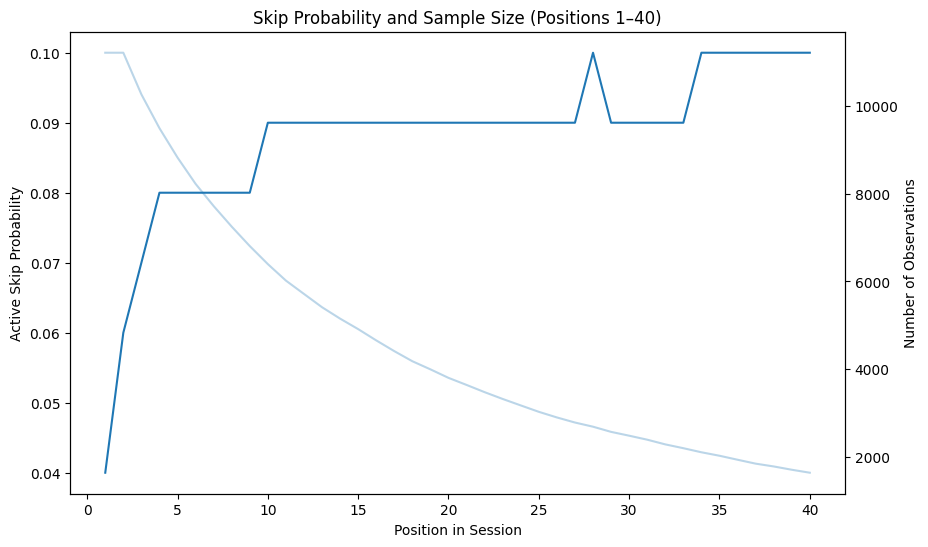

In [10]:
# Setup
max_pos = 40 
fig, ax1 = plt.subplots(figsize=(10,6))

# X variables for each plot
skip_subset = skip_by_position[skip_by_position.index <= max_pos]
counts_subset = position_count[position_count.index <= max_pos]

# Main plot showcases relationship between position in session and skip probability
ax1.plot(skip_subset.index, skip_subset.values)
ax1.set_xlabel("Position in Session")
ax1.set_ylabel("Active Skip Probability")

# Second plot showing distribution of position_ids
ax2 = ax1.twinx()
ax2.plot(counts_subset.index, counts_subset.values, alpha=0.3)
ax2.set_ylabel("Number of Observations")

plt.title("Skip Probability and Sample Size (Positions 1–40)")
plt.show()

Takeaway: There is a calibration phase from songs 1-4. First couple songs are chosen intentionally with a lower skip probabilty starting at 4% on song 1. This skip probability increases incrementally until song #4, at which point it roughly stabilizes between 8-9%. 

## Novelty Modeling

### Absolute Novelty

#### Feature Creation

In [47]:
# New Feature: tracking how many cumulative times a track has been played before the current listen
df_features["lifetime_track_plays"] = (df_features.groupby("spotify_track_uri").cumcount())

# Some checks
print("Frequency Distribution \n", df_features["lifetime_track_plays"].value_counts().head(10), "\n", sep= "") # Frequency distribution of prior track plays
print("Descriptive Statistics: \n", df_features["lifetime_track_plays"].describe(), "\n", sep = "") # Descriptive statistics for prior track plays
print("Distribution of skip probability: \n", round(df_features.groupby("lifetime_track_plays")["active_skip"].mean() * 100,2), sep= "") # Percentage chance of skipping by amount of prior track plays


Frequency Distribution 
lifetime_track_plays
0    21786
1    11796
2     7746
3     6042
4     4942
5     4316
6     3889
7     3590
8     3327
9     3131
Name: count, dtype: int64

Descriptive Statistics: 
count    240396.000000
mean         62.575159
std          79.757894
min           0.000000
25%           6.000000
50%          33.000000
75%          88.000000
max         620.000000
Name: lifetime_track_plays, dtype: float64

Distribution of skip probability: 
lifetime_track_plays
0        9.95
1       10.18
2       10.24
3       10.29
4       10.62
        ...  
616      0.00
617      0.00
618      0.00
619    100.00
620      0.00
Name: active_skip, Length: 621, dtype: float64


The most common occurence is for a track to never have been played (first time listen), followed by 1 play at half the occurences and then a gradual tapering off. The median song is played 33 times, which is again skewed right by some favorites that are played a significant amount of times. Seems like skip probability is about the same regardless of how many absolute times a track has been played before though. 

### Relative Novelty

Motivation: Since absolute novelty doesn't have much of an impact on skip behavior, what about relative novelty? Ie. how long has it been since the last time that track has been played? 

#### Feature Creation

In [12]:
# New Feature: number of days since the last time a track has been played
df_features["days_since_last_track_play"] = (df_features.groupby("spotify_track_uri")["timestamp"].diff().dt.total_seconds() / (60*60*24))

# New Feature: True/False identifying new tracks
df_features["is_first_listen"] = df_features["days_since_last_track_play"].isna()

In [51]:
# Dataframe of only repeat songs
df_repeats = df_features[~df_features["is_first_listen"]].copy()

# Create recency buckets (days)
bins = [-0.001, 1, 7, 30, 90, 365, float("inf")]
labels = ["≤1d", "1–7d", "7–30d", "30–90d", "90–365d", "1y+"]

df_repeats["recency_bin"] = pd.cut(df_repeats["days_since_last_track_play"], bins=bins, labels=labels)

# Skip rates by bin 
skip_by_recency = df_repeats.groupby("recency_bin")["active_skip"].mean()
counts_by_recency = df_repeats.groupby("recency_bin").size()

print(counts_by_recency)

recency_bin
≤1d        104971
1–7d        55244
7–30d       30431
30–90d      15205
90–365d      9825
1y+          2934
dtype: int64


The most common bucket is songs that have been played within the last day. Frequency falls off bit by bit with each longer been. Most of the time I play a song, it's something I've played relatively recently. 

#### Graphing Probabilty of Active Skip by Recency Bucket

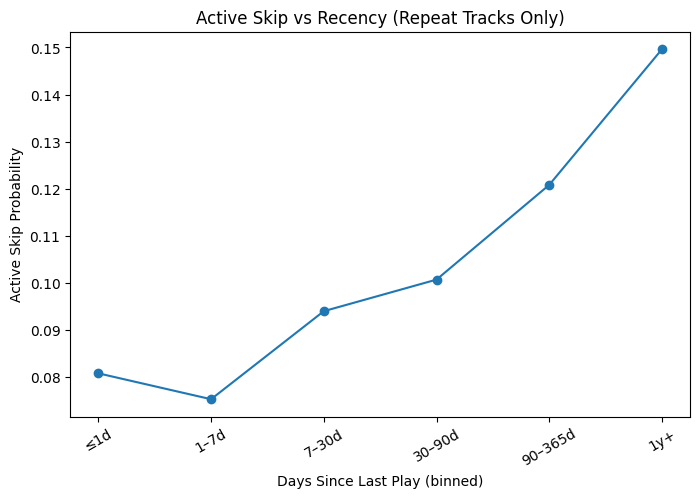

recency_bin
≤1d        0.080784
1–7d       0.075284
7–30d      0.093983
30–90d     0.100691
90–365d    0.120814
1y+        0.149625
Name: active_skip, dtype: float64


In [52]:
# Plot
plt.figure(figsize=(8,5))
plt.plot(skip_by_recency.index.astype(str), skip_by_recency.values, marker="o")
plt.xlabel("Days Since Last Play (binned)")
plt.ylabel("Active Skip Probability")
plt.title("Active Skip vs Recency (Repeat Tracks Only)")
plt.xticks(rotation=30)
plt.show()

print(skip_by_recency)

It seems recency is an indicator of ongoing relevance. The longer its been since I've played a song, the more likely I am to skip it. This is surprising. I had initially thought that nostalgia would result in me more likely to finish listening to a song I haven't listened to in a while. Instead, songs that haven't been played for over a year are almost twice as likely to be skipped than a song I played last week. 

## Session Level Table

Motivation: Let's analyze behavior within each listening session to see what features separate longer sessions from shorter ones

#### Session Level Table Creation

In [53]:
# Termination events 
termination_set = {
    "endplay",
    "logout",
    "unexpected-exit",
    "unexpected-exit-while-paused",
    "remote"
}

# New Feature: Boolean flag for whether a session termination event occured
df_features["termination_event"] = df_features["reason_end"].isin(termination_set)

# Creation of session level dataframe by grouping by session_id and aggregating information into other columns
df_sessions = df_features.groupby("session_id").agg(
    session_len=("spotify_track_uri", "size"), # number of tracks in session
    session_start=("timestamp", "min"), # session start time
    session_end=("timestamp", "max"), # session end time
    skip_rate=("active_skip", "mean"), # average amount of skips in the session
    first_listen_rate=("is_first_listen", "mean"), # Average number of new songs in session
    mean_recency_days=("days_since_last_track_play", "mean"), # Average number of days its been since all tracks have been listened to
    term_present=("termination_event", "max"), # Flags whether the listening session had a termination events
).reset_index()

# New Session Level Feature: Length of session in minutes
df_sessions["session_duration_minutes"] = (df_sessions["session_end"] - df_sessions["session_start"]).dt.total_seconds() / 60

# New Session Level Feature: Boolean flag for whether a session is a long session or not
df_sessions["long_session"] = df_sessions["session_len"] > 10

df_sessions

,session_id,session_len,session_start,session_end,skip_rate,first_listen_rate,mean_recency_days,term_present,session_duration_minutes,long_session
0,1,5,2017-08-27 22:17:18+00:00,2017-08-27 22:32:35+00:00,0.200000,1.000000,NaN,True,15.283333,False
1,3,44,2017-08-28 21:44:20+00:00,2017-08-29 00:10:30+00:00,0.250000,0.909091,0.508371,True,146.166667,True
2,4,10,2017-08-29 00:44:20+00:00,2017-08-29 02:07:20+00:00,0.100000,0.600000,0.114488,True,83.000000,False
3,5,36,2017-08-29 22:53:12+00:00,2017-08-30 00:53:01+00:00,0.194444,0.222222,0.815303,True,119.816667,True
4,6,8,2017-08-30 03:09:54+00:00,2017-08-30 03:22:20+00:00,0.125000,0.250000,0.097755,True,12.433333,False
...,...,...,...,...,...,...,...,...,...,...
11207,13988,6,2026-02-02 13:47:52+00:00,2026-02-02 13:50:12+00:00,0.000000,0.000000,0.772305,True,2.333333,False
11208,13989,3,2026-02-02 17:31:32+00:00,2026-02-02 17:36:28+00:00,0.000000,0.000000,1.219769,True,4.933333,False
11209,13990,39,2026-02-02 18:30:41+00:00,2026-02-02 20:24:41+00:00,0.102564,0.000000,5.134731,True,114.000000,True
11210,13991,8,2026-02-02 21:14:56+00:00,2026-02-02 21:31:28+00:00,0.125000,0.000000,1.532639,True,16.533333,False


#### Analysis:

In [ ]:
# Average session level metrics by whether the session is a long session or not
df_sessions.groupby("long_session")[["mean_recency_days","first_listen_rate","skip_rate","session_len","session_duration_minutes"]].mean()

,mean_recency_days,first_listen_rate,skip_rate,session_len,session_duration_minutes
long_session,,,,,
False,19.474172,0.074815,0.043412,5.238544,15.299673
True,24.910712,0.081952,0.082283,35.424892,83.335388


Longer sessions on average contain music that is "older" (less recently played tracks). Interestingly, the rate of first time listens is also higher in longer sessions, although not by a lot. Although we set the bondary at 10 songs in a session, long_sessions are 35 songs on average and 83 minutes, which is pretty sizable and distinct from the short sessions. 

In [ ]:
# Correlation between session length, skip rate, mean recency, and first listen rate
df_sessions[["session_len", "skip_rate", "mean_recency_days", "first_listen_rate"]].corr()

,session_len,skip_rate,mean_recency_days,first_listen_rate
session_len,1.000000,0.119645,0.043862,0.051770
skip_rate,0.119645,1.000000,0.043194,0.023185
mean_recency_days,0.043862,0.043194,1.000000,0.196948
first_listen_rate,0.051770,0.023185,0.196948,1.000000


Seems long long sessions listen to songs that are less recent, have a bit more novelty, and higher skip rate. So more exploratory and interactive perhaps. Takeaway: Skip is engagement, not necessariliy frustration or disatisfaction. It is not negatively correlated with session length. 

## Early Session Level Features

Motivation: Within the first 3 songs in a listening session, what behavior leads to that session becoming a long one? Could it simply be user engagement? 

#### Feature Creation:

In [ ]:
# New Feature: Active intervention, adds backbutton and click row as signals of engagement
df_features["active_intervention"] = (
    df_features["reason_end"].isin(["fwdbtn", "backbtn"]) |
    df_features["reason_start"].isin(["clickrow"])
)

# New dataframe keeps only the first 3 rows of every session
df_early_events = df_features[df_features["position_id"] <= 3].copy()

# New Feature: Boolean flag for whether a track is a repeat listen or not (ie. whether the days since last track play is NaN or not)
df_early_events["is_repeat"] = ~df_early_events["days_since_last_track_play"].isna() 

# Session level aggregation of early session metrics
df_early_sessions = df_early_events.groupby("session_id").agg(
    early_intervention_rate=("active_intervention", "mean"),
    early_first_listen_rate=("is_first_listen", "mean"),
    early_repeat_rate=("is_repeat", "mean"),
    early_mean_recency=("days_since_last_track_play", "mean"),  # mean over repeats only (NaNs ignored)
).reset_index()

# Merging early events table and session level table to create modeling dataframe
df_model = df_sessions.merge(df_early_sessions, on="session_id", how="left")

df_model[[
    "session_len",
    "early_intervention_rate",
    "early_first_listen_rate",
    "early_mean_recency"
]].describe()

,session_len,early_intervention_rate,early_first_listen_rate,early_mean_recency
count,11212.000000,11212.000000,11212.000000,11066.000000
mean,21.440956,0.307394,0.073448,18.673968
std,29.795386,0.316986,0.190818,67.454365
min,2.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,0.495278
50%,12.000000,0.333333,0.000000,1.939570
75%,26.000000,0.666667,0.000000,9.164922
max,657.000000,1.000000,1.000000,2019.227488


#### Analysis:

In [19]:
df_model[[
    "long_session",
    "early_intervention_rate",
    "early_first_listen_rate",
    "early_mean_recency"
]].corr()

,long_session,early_intervention_rate,early_first_listen_rate,early_mean_recency
long_session,1.000000,0.061190,-0.013133,-0.001225
early_intervention_rate,0.061190,1.000000,0.087006,0.060098
early_first_listen_rate,-0.013133,0.087006,1.000000,0.110950
early_mean_recency,-0.001225,0.060098,0.110950,1.000000


Early intervention has a r= .06 correlation with long sessions. So there's a small effect of early intervention resulting in longer sessions.

In [20]:
df_model.groupby("long_session")[
    ["early_intervention_rate", "early_first_listen_rate", "early_mean_recency"]
].mean()

,early_intervention_rate,early_first_listen_rate,early_mean_recency
long_session,,,
False,0.286516,0.076146,18.763103
True,0.325413,0.071120,18.597354


Again we see that sessions n>10 are more likely to have had intervention in the first 3 songs

# Logistic Regression Model

Motivation: Can we create a logistic model to predict session length? 

#### Model Creation:

In [62]:
# Target
df_model["long_session"] = df_model["session_len"] > 10

# Missing recency handling
df_model["early_recency_missing"] = df_model["early_mean_recency"].isna().astype(int)

# Fill missing with 0 (since we have missing flag)
df_model["early_mean_recency_filled"] = df_model["early_mean_recency"].fillna(0)

features = [
    "early_intervention_rate",
    "early_first_listen_rate",
    "early_mean_recency_filled",
    "early_recency_missing"
]

X = df_model[features]
y = df_model["long_session"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Model Evaluation:

In [ ]:
# AUC and classification report
pred_proba = clf.predict_proba(X_test)[:, 1]
pred = clf.predict(X_test)

print("AUC:", roc_auc_score(y_test, pred_proba))
print(classification_report(y_test, pred))

AUC: 0.5419192648190916
              precision    recall  f1-score   support

           0       0.59      0.04      0.07      1299
           1       0.54      0.98      0.70      1504

    accuracy                           0.54      2803
   macro avg       0.56      0.51      0.38      2803
weighted avg       0.56      0.54      0.41      2803



In [23]:
coef_table = pd.DataFrame({
    "feature": features,
    "coef": clf.coef_[0]
}).sort_values("coef", ascending=False)

coef_table["odds_ratio"] = np.exp(coef_table["coef"])
coef_table

,feature,coef,odds_ratio
0,early_intervention_rate,0.378141,1.459569
2,early_mean_recency_filled,-0.000164,0.999836
1,early_first_listen_rate,-0.094869,0.909492
3,early_recency_missing,-0.140357,0.869048


### Plots

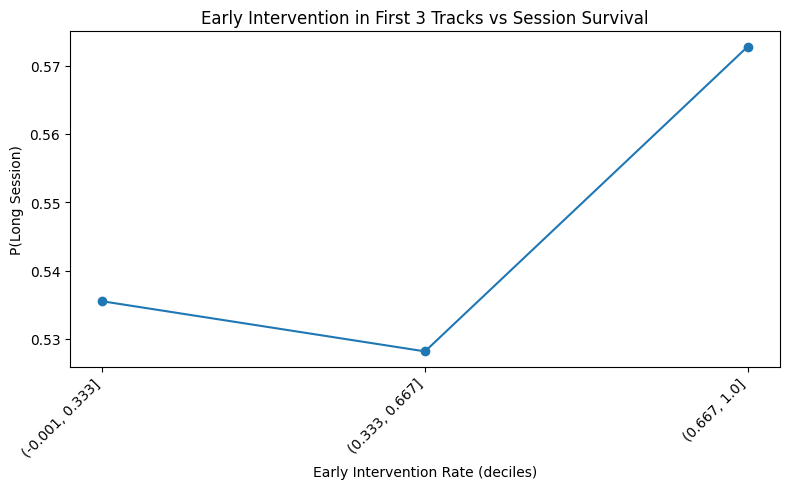

In [ ]:
# Plot the relationship between early intervention rate and probability of a long session, binned by deciles of early intervention rate
tmp = df_model.copy()
tmp["intervention_bin"] = pd.qcut(tmp["early_intervention_rate"], q=10, duplicates="drop")

# Calculate mean long session probability for each intervention bin
plot_df = tmp.groupby("intervention_bin")["long_session"].mean()
x = np.arange(len(plot_df))

plt.figure(figsize=(8,5))
plt.plot(x, plot_df.values, marker="o")
plt.xticks(x, [str(i) for i in plot_df.index], rotation=45, ha="right")
plt.ylabel("P(Long Session)")
plt.xlabel("Early Intervention Rate (deciles)")
plt.title("Early Intervention in First 3 Tracks vs Session Survival")
plt.tight_layout()
plt.show()

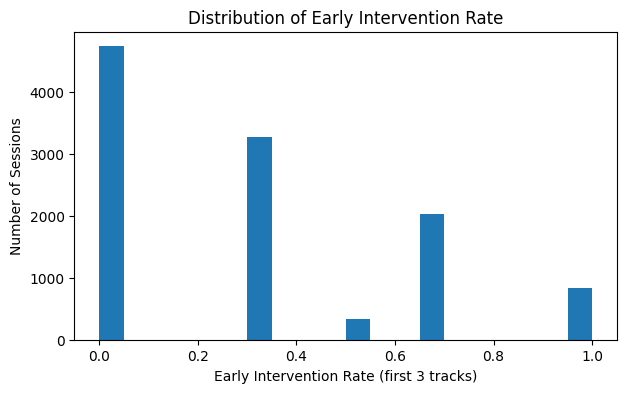

In [25]:
plt.figure(figsize=(7,4))
plt.hist(df_model["early_intervention_rate"], bins=20)
plt.xlabel("Early Intervention Rate (first 3 tracks)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Early Intervention Rate")
plt.show()

Sessions with 2–3 early overrides are ~4–5 percentage points more likely to become long sessions compared to sessions with no early intervention.